In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
prices_0 = pd.read_csv("data/prices_round_3_day_0.csv", delimiter=';')
prices_1 = pd.read_csv("data/prices_round_3_day_1.csv", delimiter=';')
prices_2 = pd.read_csv("data/prices_round_3_day_2.csv", delimiter=';')

trades_0 = pd.read_csv("data/trades_round_3_day_0.csv", delimiter=';')
trades_1 = pd.read_csv("data/trades_round_3_day_1.csv", delimiter=';')
trades_2 = pd.read_csv("data/trades_round_3_day_2.csv", delimiter=';')

OFFSET = 1_000_000

prices_0['global_timestamp'] = prices_0['timestamp'] + 0 * OFFSET
prices_1['global_timestamp'] = prices_1['timestamp'] + 1 * OFFSET
prices_2['global_timestamp'] = prices_2['timestamp'] + 2 * OFFSET

prices_all = pd.concat([prices_0, prices_1, prices_2], ignore_index=True).sort_values('global_timestamp').reset_index(drop=True)
print(prices_all.shape)
prices_all.head()

(360000, 18)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_timestamp
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0,0
1,0,0,VEV_6000,0,25,NaN,NaN,NaN,NaN,1,25,NaN,NaN,NaN,NaN,0.5,0.0,0
2,0,0,VEV_5100,169,19,NaN,NaN,NaN,NaN,174,19,NaN,NaN,NaN,NaN,171.5,0.0,0
3,0,0,VEV_4000,1240,7,1237.0,24.0,NaN,NaN,1260,7,1263.0,24.0,NaN,NaN,1250.0,0.0,0
4,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0,0


In [6]:
products = prices_all['product'].unique()
print(f"{len(products)} products:", sorted(products))

product_dfs = {product: prices_all[prices_all['product'] == product].copy() for product in products}

12 products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


In [7]:

# Extract VELVETFRUIT_EXTRACT data
vf = product_dfs['VELVETFRUIT_EXTRACT'].copy().reset_index(drop=True)
vf['spread'] = vf['ask_price_1'] - vf['bid_price_1']
vf['mid'] = (vf['bid_price_1'] + vf['ask_price_1']) / 2

# Separate by day for per-day analysis
vf_days = {d: vf[vf['day'] == d].copy() for d in vf['day'].unique()}

print(f"Total ticks: {len(vf)}")
print(f"Days: {sorted(vf['day'].unique())}")
print(f"\nMid price stats:")
print(vf['mid'].describe())
print(f"\nSpread stats:")
print(vf['spread'].describe())
vf.head()


Total ticks: 30000
Days: [0, 1, 2]

Mid price stats:
count    30000.000000
mean      5250.098100
std         15.630415
min       5198.000000
25%       5238.500000
50%       5249.500000
75%       5262.500000
max       5300.000000
Name: mid, dtype: float64

Spread stats:
count    30000.000000
mean         4.988133
std          0.847122
min          1.000000
25%          5.000000
50%          5.000000
75%          5.000000
max          6.000000
Name: spread, dtype: float64


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_timestamp,spread,mid
0,0,0,VELVETFRUIT_EXTRACT,5247,67,NaN,NaN,NaN,NaN,5253,67,NaN,NaN,NaN,NaN,5250.0,0.0,0,6,5250.0
1,0,100,VELVETFRUIT_EXTRACT,5248,69,NaN,NaN,NaN,NaN,5253,23,5254.0,46.0,NaN,NaN,5250.5,0.0,100,5,5250.5
2,0,200,VELVETFRUIT_EXTRACT,5248,20,5247.0,40.0,NaN,NaN,5253,60,NaN,NaN,NaN,NaN,5250.5,0.0,200,5,5250.5
3,0,300,VELVETFRUIT_EXTRACT,5248,24,5247.0,40.0,NaN,NaN,5253,64,NaN,NaN,NaN,NaN,5250.5,0.0,300,5,5250.5
4,0,400,VELVETFRUIT_EXTRACT,5248,25,5247.0,37.0,NaN,NaN,5253,62,NaN,NaN,NaN,NaN,5250.5,0.0,400,5,5250.5


## 1. Price Behaviour

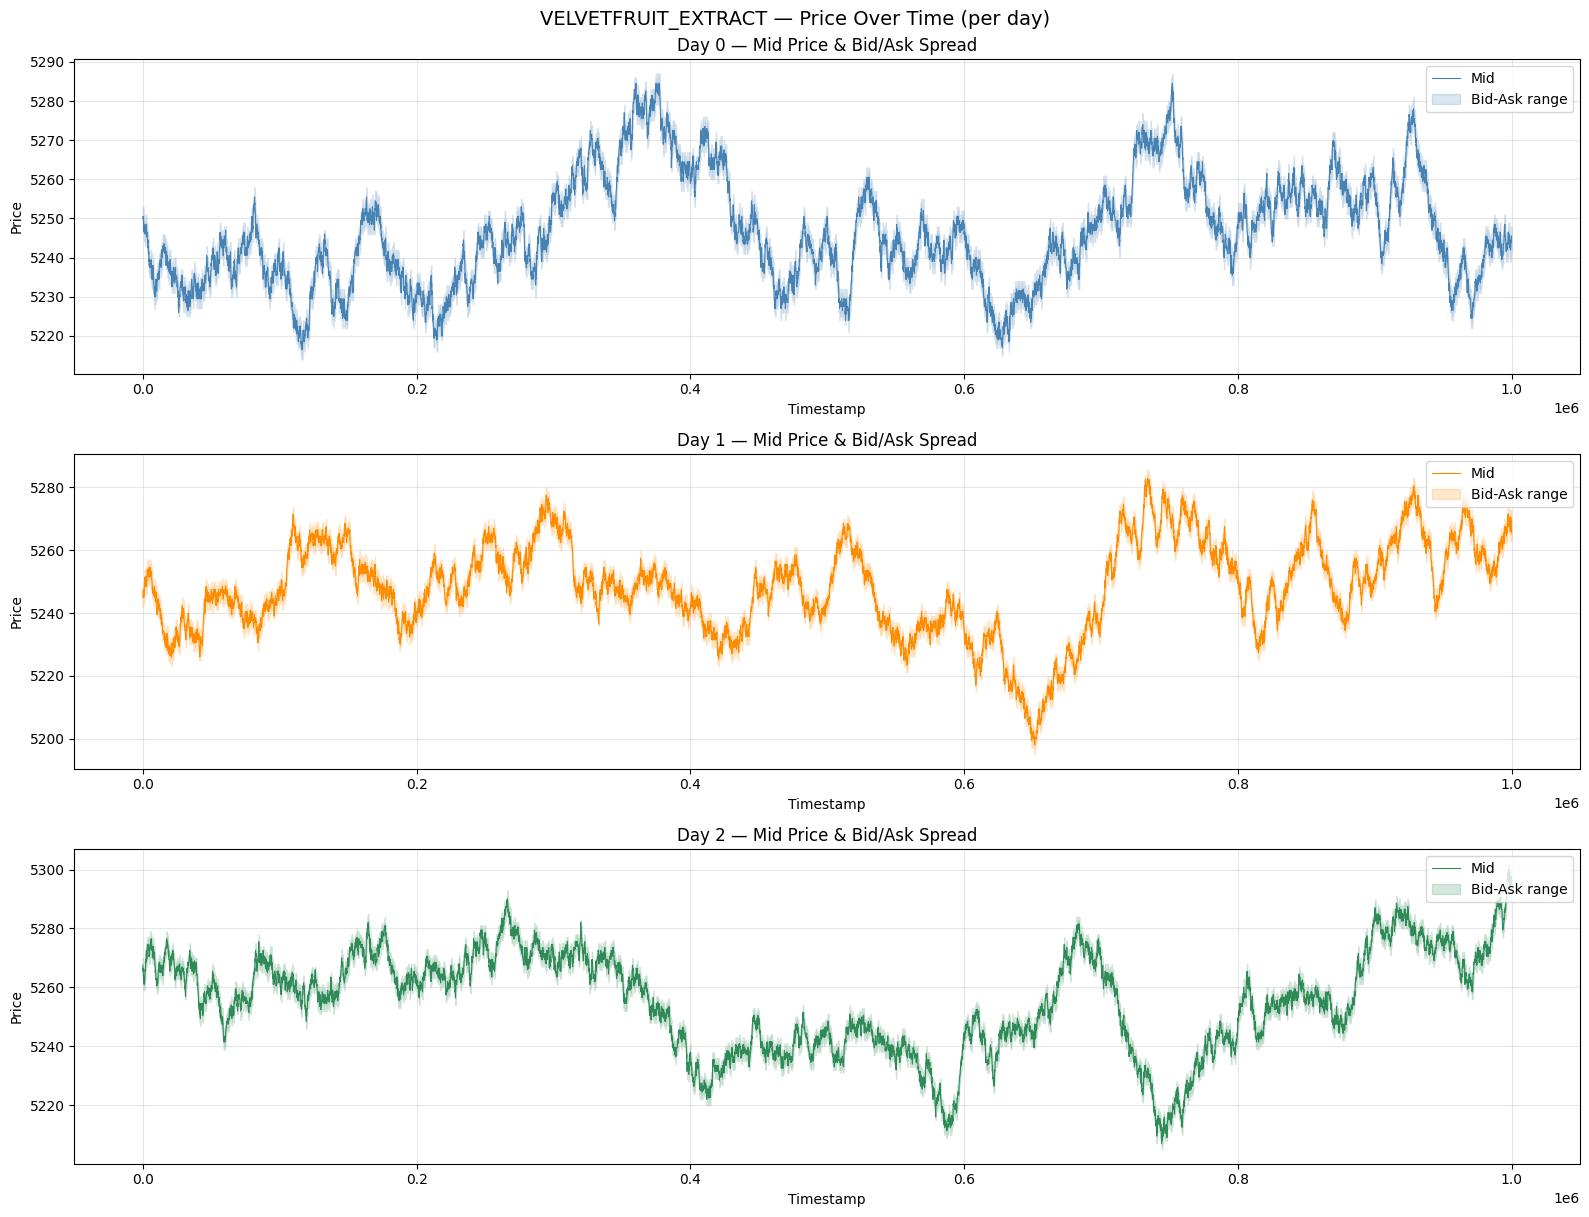

In [8]:

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=False)
colors = ['steelblue', 'darkorange', 'seagreen']

for i, (day, df) in enumerate(sorted(vf_days.items())):
    ax = axes[i]
    ax.plot(df['timestamp'], df['mid'], color=colors[i], linewidth=0.8, label='Mid')
    ax.fill_between(df['timestamp'], df['bid_price_1'], df['ask_price_1'],
                    alpha=0.2, color=colors[i], label='Bid-Ask range')
    ax.set_title(f"Day {day} — Mid Price & Bid/Ask Spread")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Price")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("VELVETFRUIT_EXTRACT — Price Over Time (per day)", y=1.01, fontsize=14)
plt.show()


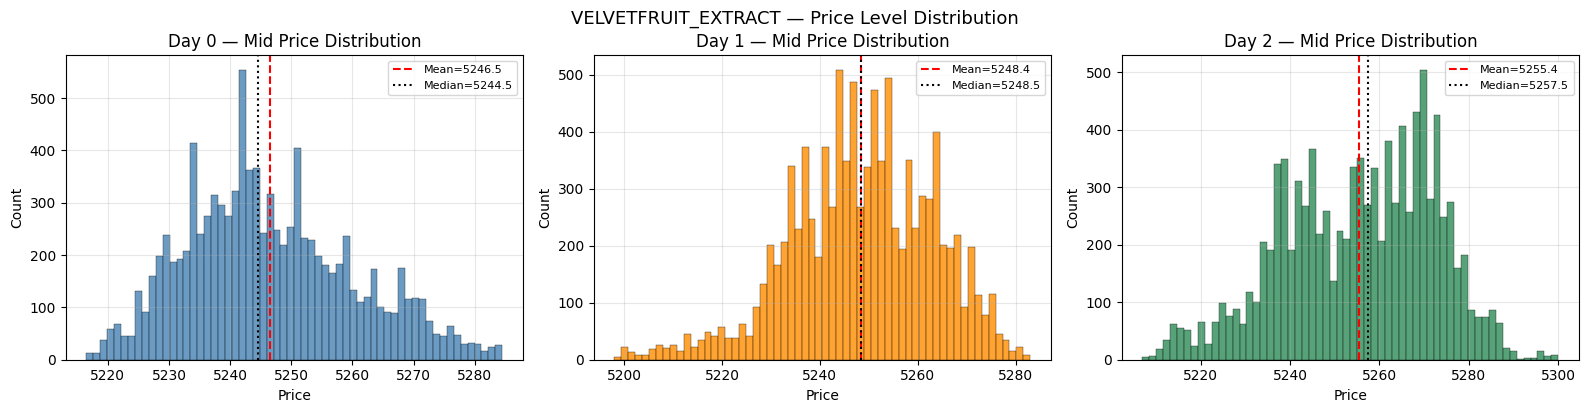

Tick-to-tick return stats:
count    29997.000000
mean         0.001417
std          1.131176
min         -5.500000
25%         -1.000000
50%          0.000000
75%          1.000000
max          5.000000
Name: mid_return, dtype: float64


In [9]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, (day, df) in enumerate(sorted(vf_days.items())):
    ax = axes[i]
    ax.hist(df['mid'], bins=60, color=colors[i], edgecolor='black', linewidth=0.3, alpha=0.8)
    ax.axvline(df['mid'].mean(), color='red', linestyle='--', label=f"Mean={df['mid'].mean():.1f}")
    ax.axvline(df['mid'].median(), color='black', linestyle=':', label=f"Median={df['mid'].median():.1f}")
    ax.set_title(f"Day {day} — Mid Price Distribution")
    ax.set_xlabel("Price")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle("VELVETFRUIT_EXTRACT — Price Level Distribution", y=1.02, fontsize=13)
plt.show()

# Price returns analysis
vf['mid_return'] = vf.groupby('day')['mid'].diff()
print("Tick-to-tick return stats:")
print(vf['mid_return'].describe())


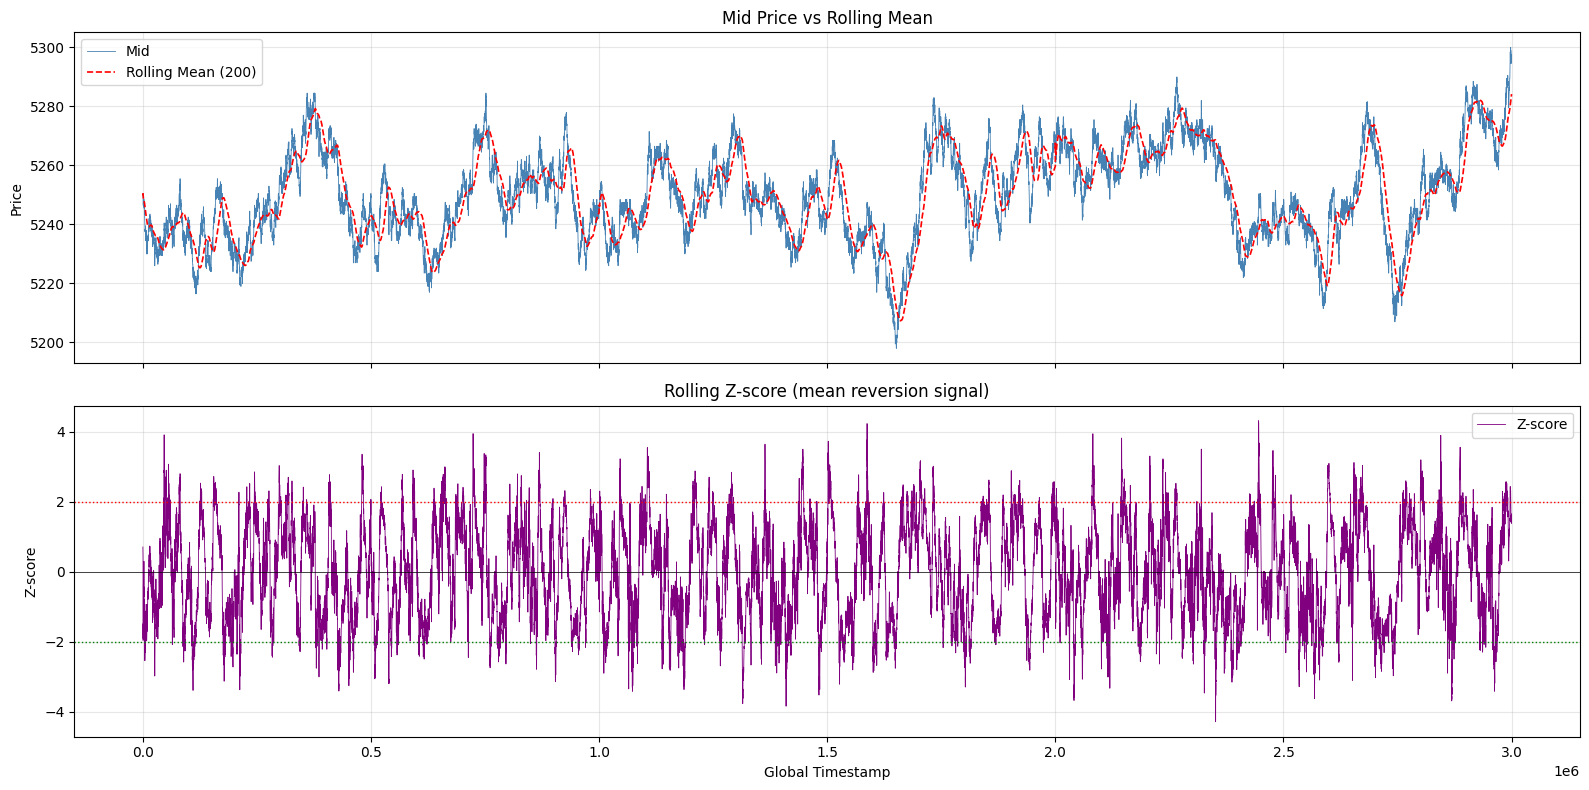

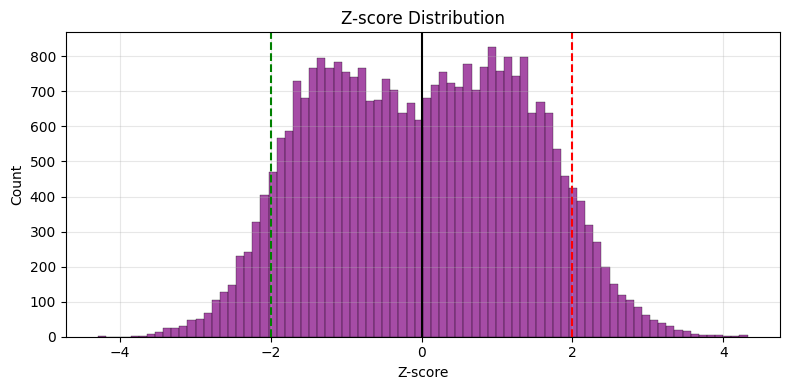

Ticks with |z| > 2: 4116 (13.7%)


In [10]:

# Rolling volatility and mean-reversion signal
WINDOW = 200
vf['rolling_mean'] = vf.groupby('day')['mid'].transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
vf['rolling_std']  = vf.groupby('day')['mid'].transform(lambda x: x.rolling(WINDOW, min_periods=2).std())
vf['z_score'] = (vf['mid'] - vf['rolling_mean']) / vf['rolling_std'].replace(0, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(vf['global_timestamp'], vf['mid'], linewidth=0.6, color='steelblue', label='Mid')
axes[0].plot(vf['global_timestamp'], vf['rolling_mean'], linewidth=1.2, color='red', linestyle='--', label=f'Rolling Mean ({WINDOW})')
axes[0].set_ylabel("Price"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Mid Price vs Rolling Mean")

axes[1].plot(vf['global_timestamp'], vf['z_score'], linewidth=0.6, color='purple', label='Z-score')
axes[1].axhline(2, color='red', linestyle=':', linewidth=1)
axes[1].axhline(-2, color='green', linestyle=':', linewidth=1)
axes[1].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_ylabel("Z-score"); axes[1].set_xlabel("Global Timestamp"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Rolling Z-score (mean reversion signal)")

plt.tight_layout()
plt.show()

# Z-score distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(vf['z_score'].dropna(), bins=80, color='purple', alpha=0.7, edgecolor='black', linewidth=0.3)
ax.axvline(0, color='black'); ax.axvline(2, color='red', linestyle='--'); ax.axvline(-2, color='green', linestyle='--')
ax.set_xlabel("Z-score"); ax.set_ylabel("Count"); ax.set_title("Z-score Distribution")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Ticks with |z| > 2: {(vf['z_score'].abs() > 2).sum()} ({(vf['z_score'].abs() > 2).mean()*100:.1f}%)")


## 2. Microstructure Features

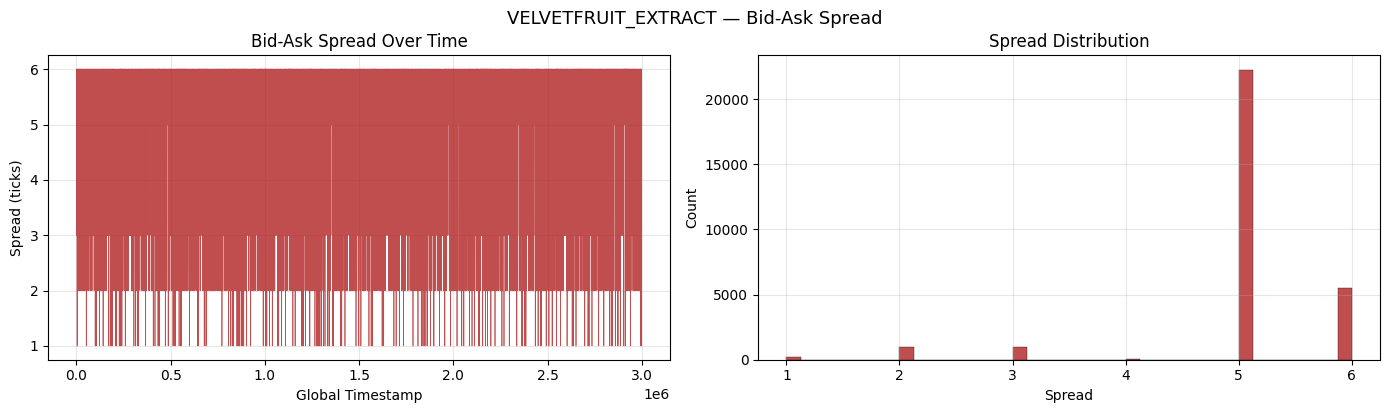

Spread value counts (most common):
spread
5    22259
6     5475
2     1014
3     1003
1      178
4       71
Name: count, dtype: int64

Mean spread: 4.988
Spread = 1 tick: 0.6%
Spread = 2 ticks: 3.4%


In [11]:

# Bid-ask spread analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(vf['global_timestamp'], vf['spread'], linewidth=0.5, color='firebrick', alpha=0.8)
axes[0].set_title("Bid-Ask Spread Over Time")
axes[0].set_xlabel("Global Timestamp"); axes[0].set_ylabel("Spread (ticks)"); axes[0].grid(alpha=0.3)

axes[1].hist(vf['spread'].dropna(), bins=40, color='firebrick', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[1].set_title("Spread Distribution")
axes[1].set_xlabel("Spread"); axes[1].set_ylabel("Count"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("VELVETFRUIT_EXTRACT — Bid-Ask Spread", y=1.02, fontsize=13)
plt.show()

print("Spread value counts (most common):")
print(vf['spread'].value_counts().head(10))
print(f"\nMean spread: {vf['spread'].mean():.3f}")
print(f"Spread = 1 tick: {(vf['spread'] == 1).mean()*100:.1f}%")
print(f"Spread = 2 ticks: {(vf['spread'] == 2).mean()*100:.1f}%")


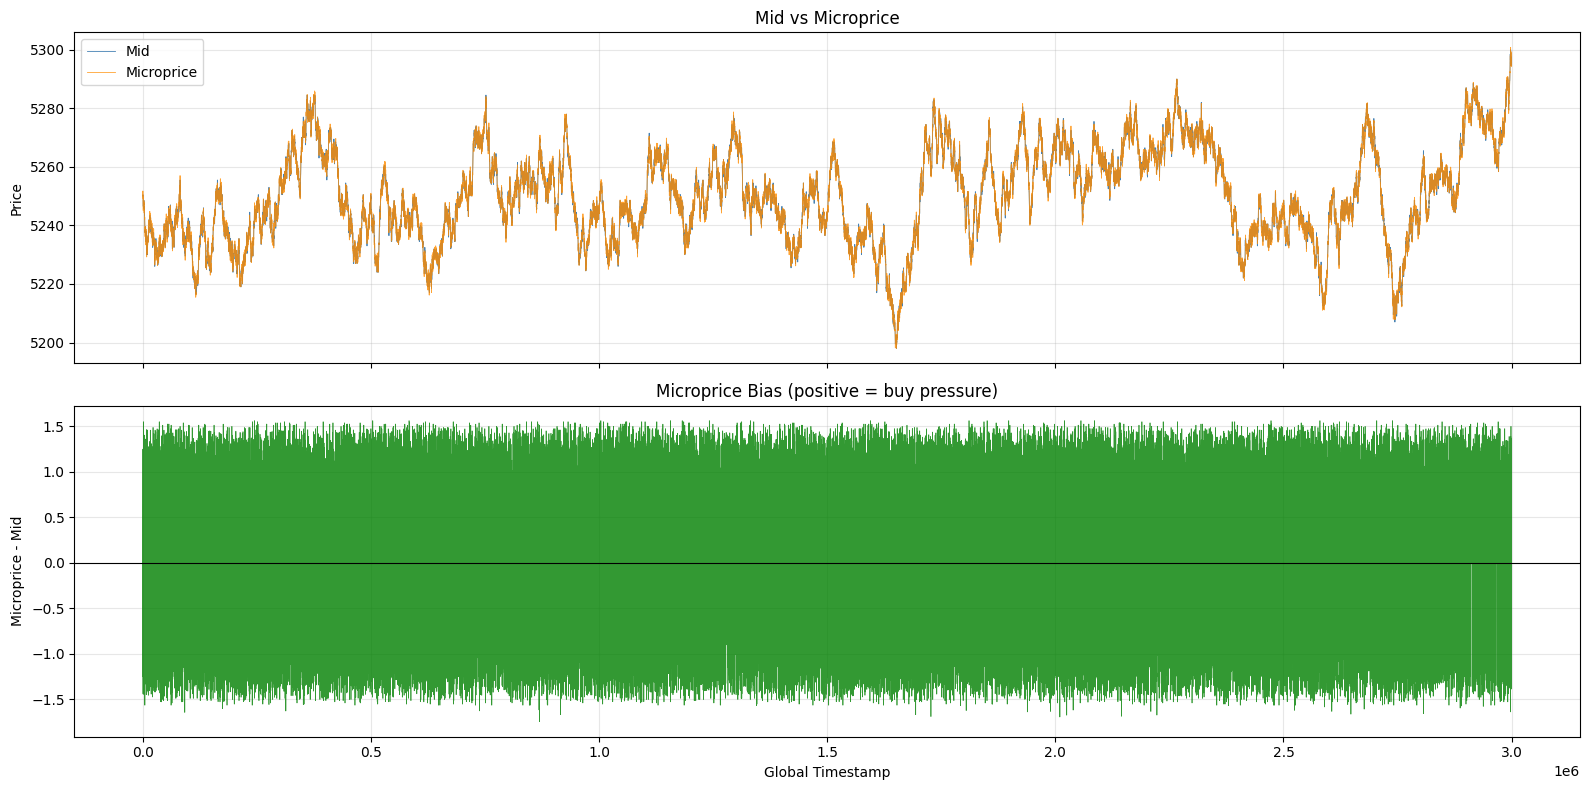

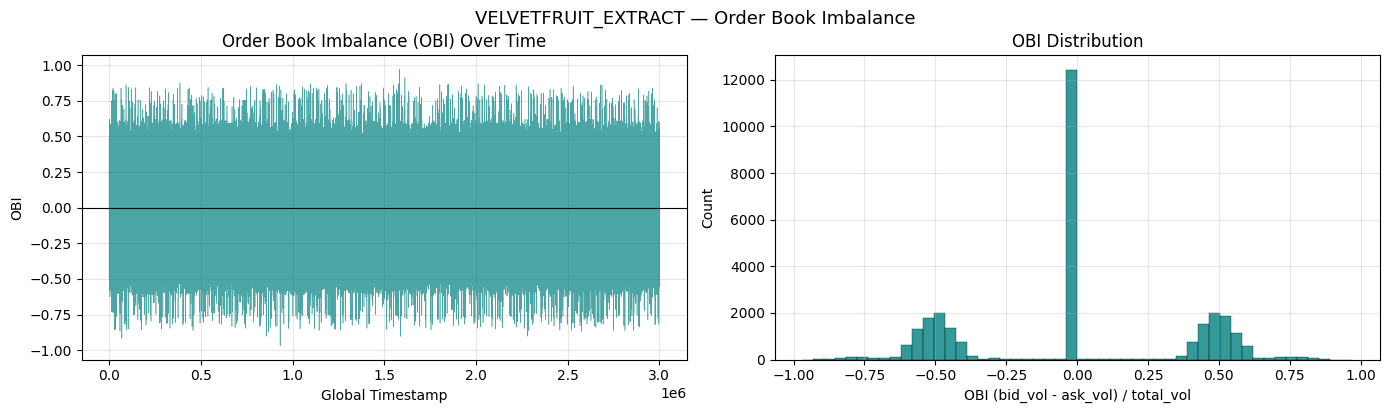

OBI stats:
count    30000.000000
mean         0.000622
std          0.394896
min         -0.968750
25%         -0.431818
50%          0.000000
75%          0.432099
max          0.971429
Name: obi, dtype: float64


In [12]:

# Microprice = volume-weighted fair value
vf['microprice'] = (
    vf['bid_price_1'] * vf['ask_volume_1'] + vf['ask_price_1'] * vf['bid_volume_1']
) / (vf['bid_volume_1'] + vf['ask_volume_1'])

vf['micro_vs_mid'] = vf['microprice'] - vf['mid']

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].plot(vf['global_timestamp'], vf['mid'], linewidth=0.6, label='Mid', color='steelblue')
axes[0].plot(vf['global_timestamp'], vf['microprice'], linewidth=0.6, label='Microprice', color='darkorange', alpha=0.8)
axes[0].set_ylabel("Price"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Mid vs Microprice")

axes[1].plot(vf['global_timestamp'], vf['micro_vs_mid'], linewidth=0.5, color='green', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel("Microprice - Mid"); axes[1].set_xlabel("Global Timestamp"); axes[1].grid(alpha=0.3)
axes[1].set_title("Microprice Bias (positive = buy pressure)")

plt.tight_layout(); plt.show()

# Order book imbalance
vf['obi'] = (vf['bid_volume_1'] - vf['ask_volume_1']) / (vf['bid_volume_1'] + vf['ask_volume_1'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(vf['global_timestamp'], vf['obi'], linewidth=0.4, color='teal', alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title("Order Book Imbalance (OBI) Over Time")
axes[0].set_xlabel("Global Timestamp"); axes[0].set_ylabel("OBI"); axes[0].grid(alpha=0.3)

axes[1].hist(vf['obi'].dropna(), bins=50, color='teal', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[1].set_title("OBI Distribution")
axes[1].set_xlabel("OBI (bid_vol - ask_vol) / total_vol"); axes[1].set_ylabel("Count"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("VELVETFRUIT_EXTRACT — Order Book Imbalance", y=1.02, fontsize=13)
plt.show()
print(f"OBI stats:\n{vf['obi'].describe()}")


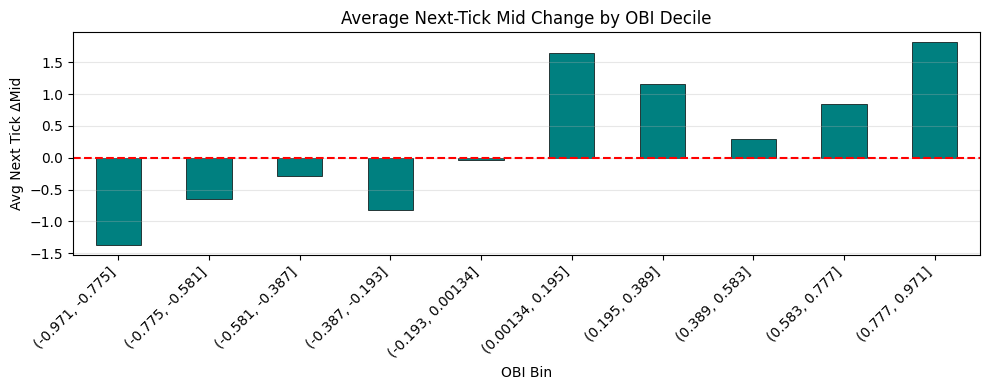

OBI → next tick correlation: 0.2806662006925832


In [13]:

# OBI predictive power: does OBI predict next-tick mid price change?
vf['next_mid_change'] = vf.groupby('day')['mid'].diff().shift(-1)
obi_bins = pd.cut(vf['obi'], bins=10)
predictive = vf.groupby(obi_bins, observed=True)['next_mid_change'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
predictive.plot(kind='bar', ax=ax, color='teal', edgecolor='black', linewidth=0.5)
ax.axhline(0, color='red', linestyle='--')
ax.set_title("Average Next-Tick Mid Change by OBI Decile")
ax.set_xlabel("OBI Bin"); ax.set_ylabel("Avg Next Tick ΔMid")
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
print("OBI → next tick correlation:", vf['obi'].corr(vf['next_mid_change']))


## 3. Intraday Patterns

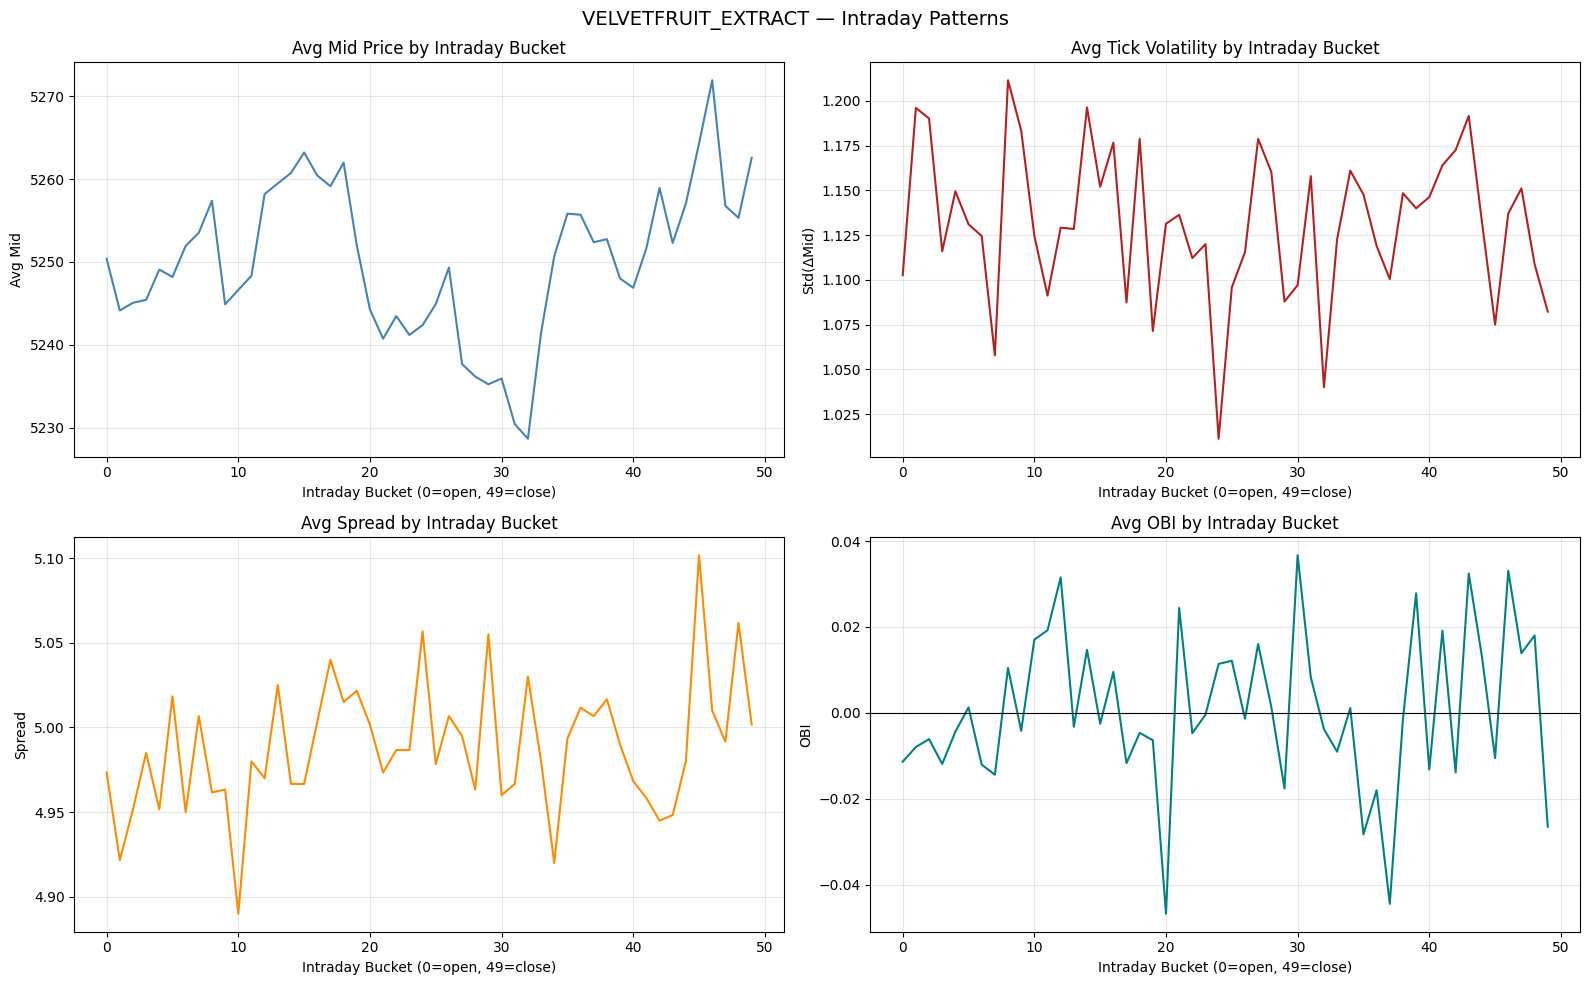

In [14]:

# Bin timestamps into 50 equal-sized intraday buckets for intraday profiles
BINS = 50
vf['ts_bin'] = pd.cut(vf['timestamp'], bins=BINS, labels=False)

# Mean mid by intraday bin (averaged across all days)
intraday_mid = vf.groupby('ts_bin')['mid'].mean()
intraday_vol  = vf.groupby('ts_bin')['mid_return'].std()
intraday_spread = vf.groupby('ts_bin')['spread'].mean()
intraday_obi   = vf.groupby('ts_bin')['obi'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(intraday_mid.index, intraday_mid.values, color='steelblue', linewidth=1.5)
axes[0,0].set_title("Avg Mid Price by Intraday Bucket"); axes[0,0].set_ylabel("Avg Mid"); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(intraday_vol.index, intraday_vol.values, color='firebrick', linewidth=1.5)
axes[0,1].set_title("Avg Tick Volatility by Intraday Bucket"); axes[0,1].set_ylabel("Std(ΔMid)"); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(intraday_spread.index, intraday_spread.values, color='darkorange', linewidth=1.5)
axes[1,0].set_title("Avg Spread by Intraday Bucket"); axes[1,0].set_ylabel("Spread"); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(intraday_obi.index, intraday_obi.values, color='teal', linewidth=1.5)
axes[1,1].axhline(0, color='black', linewidth=0.8)
axes[1,1].set_title("Avg OBI by Intraday Bucket"); axes[1,1].set_ylabel("OBI"); axes[1,1].grid(alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel("Intraday Bucket (0=open, 49=close)")

plt.suptitle("VELVETFRUIT_EXTRACT — Intraday Patterns", fontsize=14)
plt.tight_layout(); plt.show()


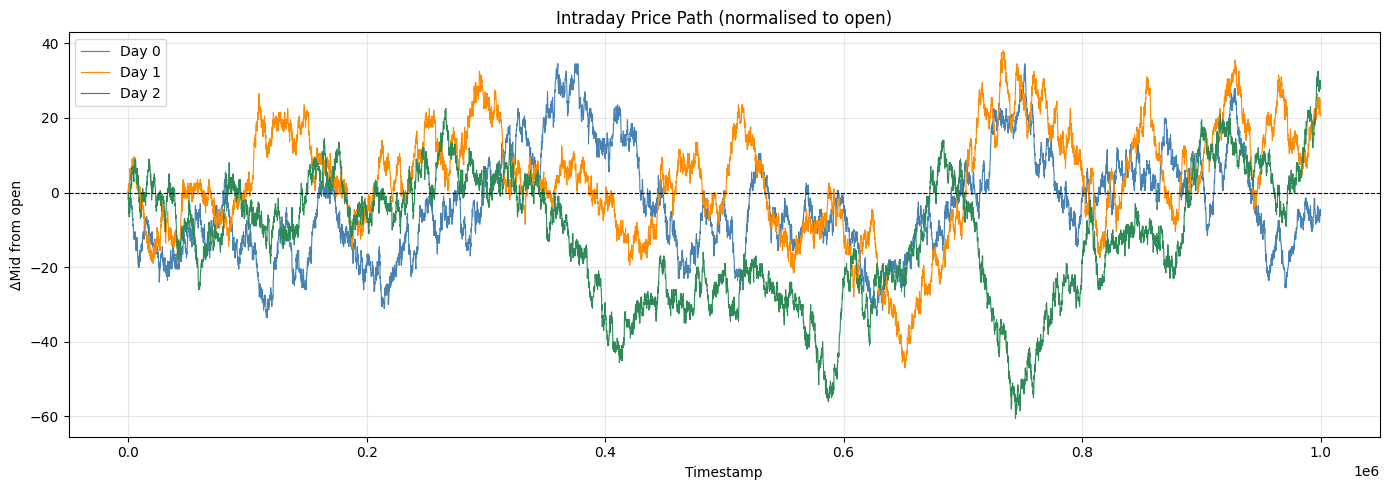

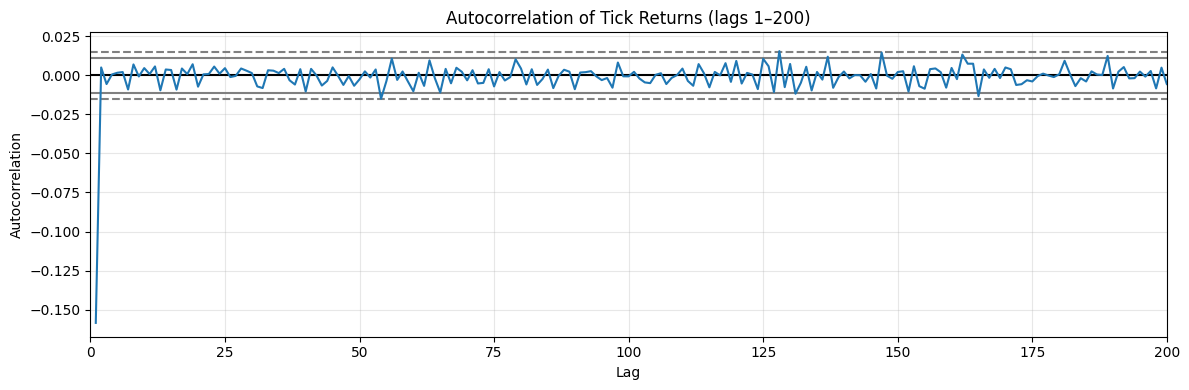

In [15]:

# Per-day intraday price path (normalised to day-open = 0)
fig, ax = plt.subplots(figsize=(14, 5))
for i, (day, df) in enumerate(sorted(vf_days.items())):
    normed = df['mid'].values - df['mid'].iloc[0]
    ax.plot(df['timestamp'].values, normed, linewidth=0.8, label=f"Day {day}", color=colors[i])

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("Intraday Price Path (normalised to open)")
ax.set_xlabel("Timestamp"); ax.set_ylabel("ΔMid from open")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Autocorrelation of returns — test for mean reversion vs momentum
from pandas.plotting import autocorrelation_plot
fig, ax = plt.subplots(figsize=(12, 4))
autocorrelation_plot(vf['mid_return'].dropna().reset_index(drop=True), ax=ax)
ax.set_xlim(0, 200)
ax.set_title("Autocorrelation of Tick Returns (lags 1–200)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Liquidity Analysis

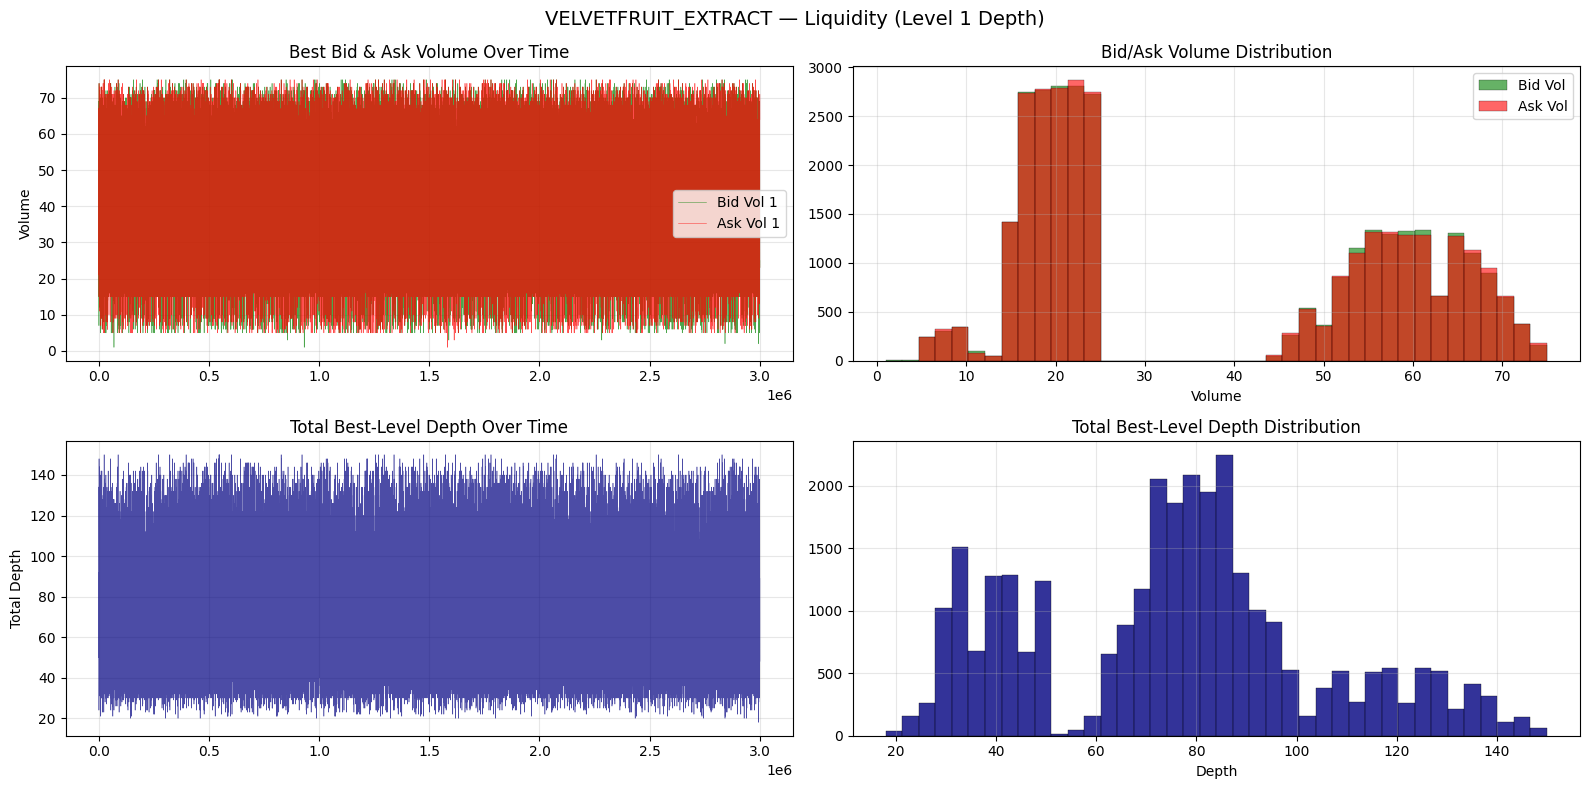

Bid volume 1 stats:
count    30000.000000
mean        37.825300
std         21.016731
min          1.000000
25%         19.000000
50%         25.000000
75%         59.000000
max         75.000000
Name: bid_volume_1, dtype: float64

Ask volume 1 stats:
count    30000.000000
mean        37.801133
std         21.054918
min          1.000000
25%         19.000000
50%         25.000000
75%         59.000000
max         75.000000
Name: ask_volume_1, dtype: float64


In [16]:

# Bid and ask volumes at level 1
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0,0].plot(vf['global_timestamp'], vf['bid_volume_1'], linewidth=0.4, color='green', alpha=0.7, label='Bid Vol 1')
axes[0,0].plot(vf['global_timestamp'], vf['ask_volume_1'], linewidth=0.4, color='red', alpha=0.7, label='Ask Vol 1')
axes[0,0].set_title("Best Bid & Ask Volume Over Time"); axes[0,0].set_ylabel("Volume"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].hist(vf['bid_volume_1'].dropna(), bins=40, color='green', alpha=0.6, label='Bid Vol', edgecolor='black', linewidth=0.3)
axes[0,1].hist(vf['ask_volume_1'].dropna(), bins=40, color='red', alpha=0.6, label='Ask Vol', edgecolor='black', linewidth=0.3)
axes[0,1].set_title("Bid/Ask Volume Distribution"); axes[0,1].set_xlabel("Volume"); axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

# Total depth at level 1
vf['total_depth_1'] = vf['bid_volume_1'] + vf['ask_volume_1']
axes[1,0].plot(vf['global_timestamp'], vf['total_depth_1'], linewidth=0.4, color='navy', alpha=0.7)
axes[1,0].set_title("Total Best-Level Depth Over Time"); axes[1,0].set_ylabel("Total Depth"); axes[1,0].grid(alpha=0.3)

axes[1,1].hist(vf['total_depth_1'].dropna(), bins=40, color='navy', alpha=0.8, edgecolor='black', linewidth=0.3)
axes[1,1].set_title("Total Best-Level Depth Distribution"); axes[1,1].set_xlabel("Depth"); axes[1,1].grid(alpha=0.3)

plt.suptitle("VELVETFRUIT_EXTRACT — Liquidity (Level 1 Depth)", fontsize=14)
plt.tight_layout(); plt.show()

print("Bid volume 1 stats:"); print(vf['bid_volume_1'].describe())
print("\nAsk volume 1 stats:"); print(vf['ask_volume_1'].describe())


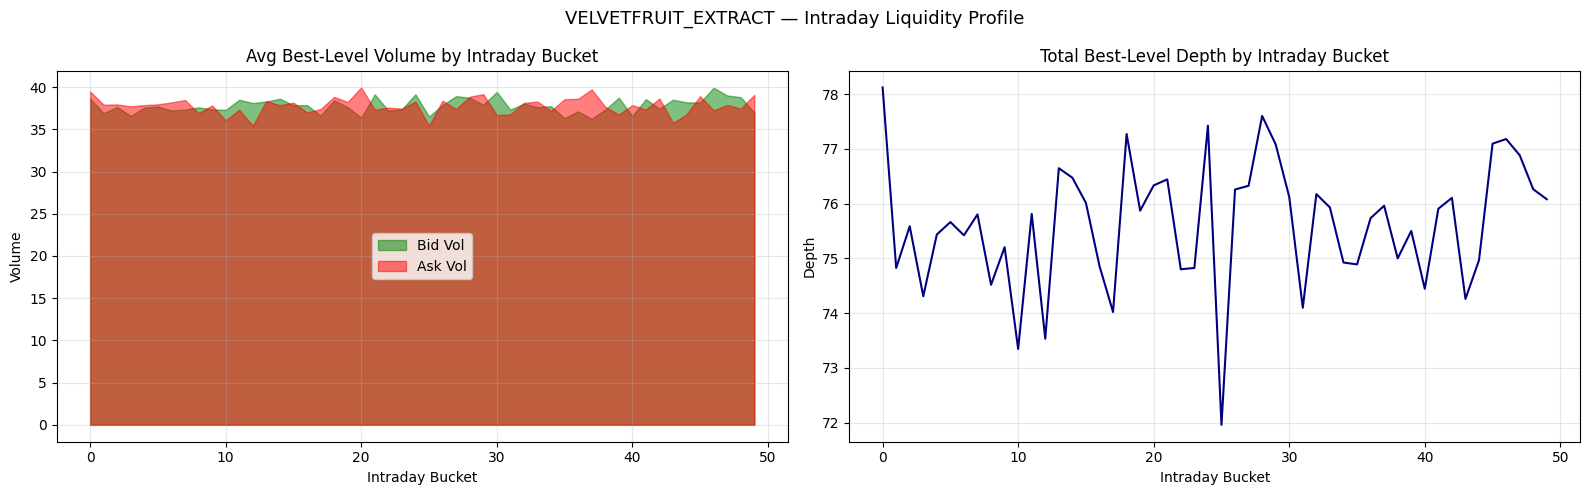

Effective spread (% of mid): mean=0.0950%, median=0.0953%
Estimated round-trip cost per unit (half-spread): 2.494 ticks


In [17]:

# Intraday liquidity patterns
intraday_depth = vf.groupby('ts_bin')['total_depth_1'].mean()
intraday_bid_vol = vf.groupby('ts_bin')['bid_volume_1'].mean()
intraday_ask_vol = vf.groupby('ts_bin')['ask_volume_1'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].fill_between(intraday_bid_vol.index, intraday_bid_vol.values, alpha=0.5, color='green', label='Bid Vol')
axes[0].fill_between(intraday_ask_vol.index, intraday_ask_vol.values, alpha=0.5, color='red', label='Ask Vol')
axes[0].set_title("Avg Best-Level Volume by Intraday Bucket")
axes[0].set_xlabel("Intraday Bucket"); axes[0].set_ylabel("Volume"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(intraday_depth.index, intraday_depth.values, color='navy', linewidth=1.5)
axes[1].set_title("Total Best-Level Depth by Intraday Bucket")
axes[1].set_xlabel("Intraday Bucket"); axes[1].set_ylabel("Depth"); axes[1].grid(alpha=0.3)

plt.suptitle("VELVETFRUIT_EXTRACT — Intraday Liquidity Profile", fontsize=13)
plt.tight_layout(); plt.show()

# Effective spread cost: fraction of spread captured by each trade
vf['eff_spread_pct'] = vf['spread'] / vf['mid'] * 100
print(f"Effective spread (% of mid): mean={vf['eff_spread_pct'].mean():.4f}%, median={vf['eff_spread_pct'].median():.4f}%")
print(f"Estimated round-trip cost per unit (half-spread): {vf['spread'].mean()/2:.3f} ticks")


## 5. Trade Data Analysis

In [18]:

# Filter trades for VELVETFRUIT_EXTRACT
trades_0['day'] = 0; trades_1['day'] = 1; trades_2['day'] = 2
trades_all = pd.concat([trades_0, trades_1, trades_2], ignore_index=True)
trades_all['global_timestamp'] = trades_all['timestamp'] + trades_all['day'] * 1_000_000

vf_trades = trades_all[trades_all['symbol'] == 'VELVETFRUIT_EXTRACT'].copy().reset_index(drop=True)
print(f"Total VELVETFRUIT trades: {len(vf_trades)}")
print(f"\nColumns: {list(vf_trades.columns)}")
print(f"\nBuyer counts (top 10):\n{vf_trades['buyer'].value_counts().head(10)}")
print(f"\nSeller counts (top 10):\n{vf_trades['seller'].value_counts().head(10)}")
vf_trades.head()


Total VELVETFRUIT trades: 1372

Columns: ['timestamp', 'buyer', 'seller', 'symbol', 'currency', 'price', 'quantity', 'day', 'global_timestamp']

Buyer counts (top 10):
Series([], Name: count, dtype: int64)

Seller counts (top 10):
Series([], Name: count, dtype: int64)


,timestamp,buyer,seller,symbol,currency,price,quantity,day,global_timestamp
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4,0,2500
1,5200,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5236.0,3,0,5200
2,5500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5241.0,8,0,5500
3,9300,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5229.0,6,0,9300
4,11900,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5237.0,4,0,11900


ValueError: Invalid frequency: 100000. Failed to parse with error message: ValueError('last element must be blank')

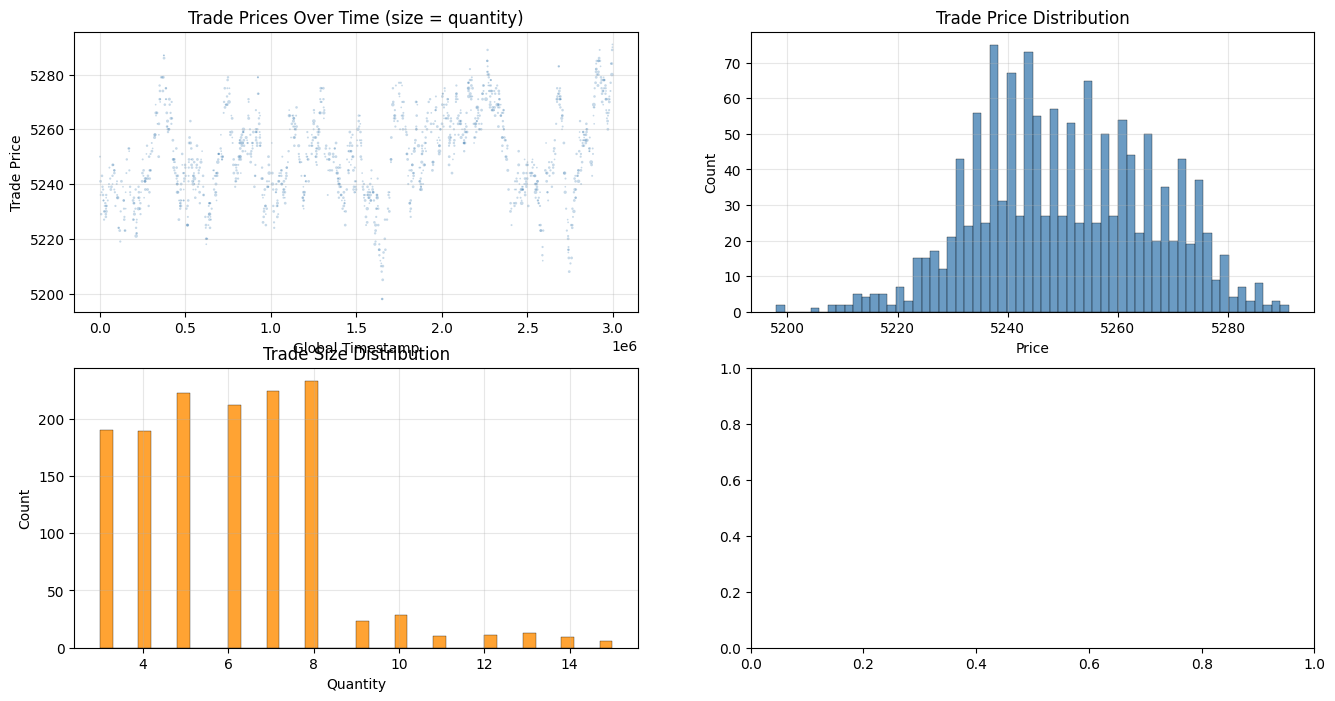

In [19]:

# Trade price and size analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

axes[0,0].scatter(vf_trades['global_timestamp'], vf_trades['price'],
                  s=vf_trades['quantity']*0.5, alpha=0.3, color='steelblue', edgecolors='none')
axes[0,0].set_title("Trade Prices Over Time (size = quantity)")
axes[0,0].set_xlabel("Global Timestamp"); axes[0,0].set_ylabel("Trade Price"); axes[0,0].grid(alpha=0.3)

axes[0,1].hist(vf_trades['price'], bins=60, color='steelblue', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[0,1].set_title("Trade Price Distribution")
axes[0,1].set_xlabel("Price"); axes[0,1].set_ylabel("Count"); axes[0,1].grid(alpha=0.3)

axes[1,0].hist(vf_trades['quantity'], bins=40, color='darkorange', edgecolor='black', linewidth=0.3, alpha=0.8)
axes[1,0].set_title("Trade Size Distribution")
axes[1,0].set_xlabel("Quantity"); axes[1,0].set_ylabel("Count"); axes[1,0].grid(alpha=0.3)

# Trade frequency over time (rolling count)
vf_trades_sorted = vf_trades.sort_values('global_timestamp')
trade_freq = vf_trades_sorted.set_index('global_timestamp')['quantity'].resample('100000').count()
trade_freq.plot(ax=axes[1,1], color='purple', linewidth=1)
axes[1,1].set_title("Trade Count per 100k Timestamp Interval")
axes[1,1].set_xlabel("Global Timestamp"); axes[1,1].set_ylabel("# Trades"); axes[1,1].grid(alpha=0.3)

plt.suptitle("VELVETFRUIT_EXTRACT — Trade Analysis", fontsize=14)
plt.tight_layout(); plt.show()

print(f"\nTrade size stats:\n{vf_trades['quantity'].describe()}")
print(f"\nTrade price stats:\n{vf_trades['price'].describe()}")


IndexError: index 0 is out of bounds for axis 0 with size 0

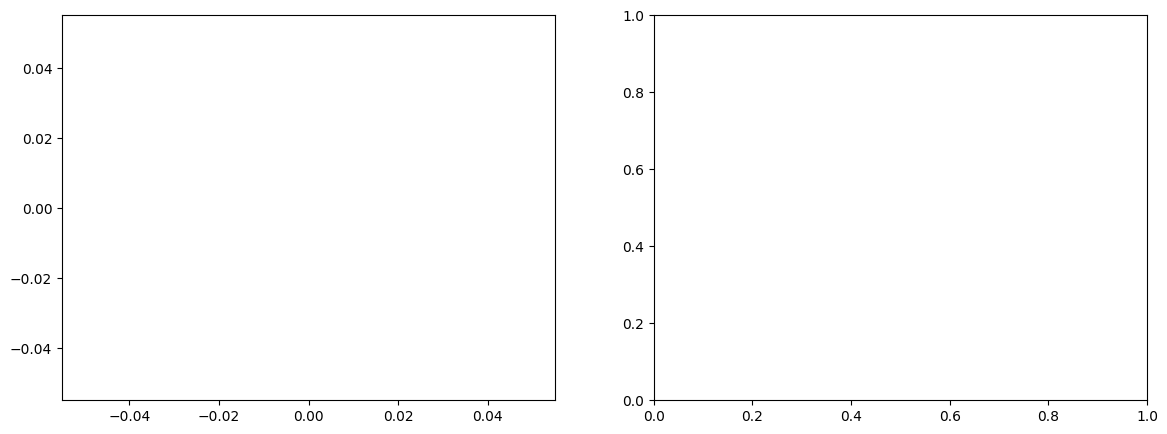

In [20]:

# Buyer / seller flow analysis — who is the aggressive side?
top_buyers  = vf_trades['buyer'].value_counts().head(8)
top_sellers = vf_trades['seller'].value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_buyers.plot(kind='barh', ax=axes[0], color='green', edgecolor='black', linewidth=0.5)
axes[0].set_title("Top Buyers (trade count)"); axes[0].set_xlabel("# Trades"); axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

top_sellers.plot(kind='barh', ax=axes[1], color='red', edgecolor='black', linewidth=0.5)
axes[1].set_title("Top Sellers (trade count)"); axes[1].set_xlabel("# Trades"); axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle("VELVETFRUIT_EXTRACT — Market Participant Activity", fontsize=13)
plt.tight_layout(); plt.show()

# Net flow per participant
buyer_vol  = vf_trades.groupby('buyer')['quantity'].sum().rename('bought')
seller_vol = vf_trades.groupby('seller')['quantity'].sum().rename('sold')
net_flow = pd.concat([buyer_vol, seller_vol], axis=1).fillna(0)
net_flow['net'] = net_flow['bought'] - net_flow['sold']
print("Net flow per participant (bought - sold):")
print(net_flow.sort_values('net', ascending=False).head(15))


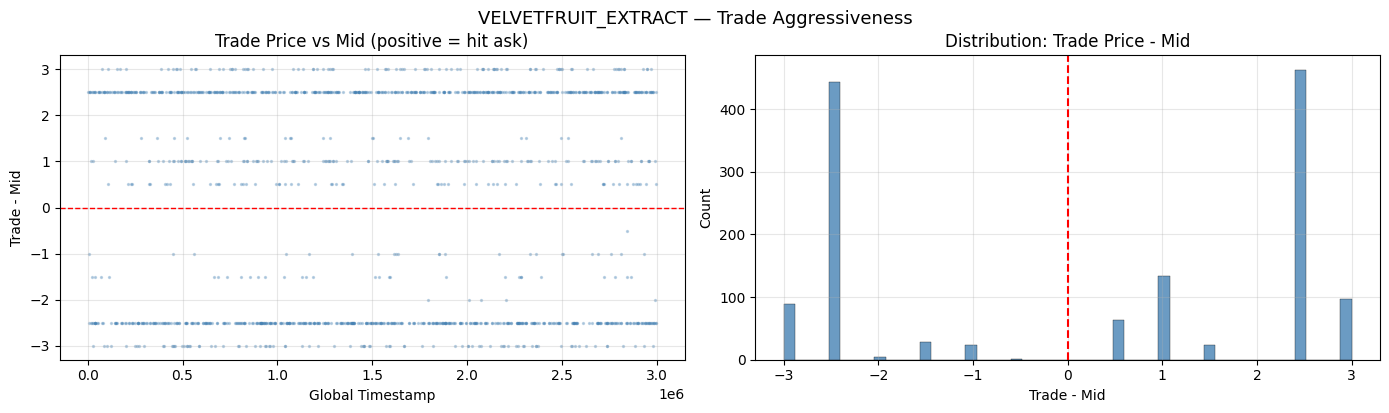

Trades hitting ask (aggressive buy): 56.9%
Trades hitting bid (aggressive sell): 43.1%
Trades at mid: 0.0%


In [21]:

# Trade price vs mid price at same tick — measure aggressiveness
# Merge trades onto price data by (day, timestamp)
vf_price_ref = vf[['day','timestamp','mid','bid_price_1','ask_price_1']].copy()
vf_trades_merged = vf_trades.merge(vf_price_ref, on=['day','timestamp'], how='left')
vf_trades_merged['trade_vs_mid'] = vf_trades_merged['price'] - vf_trades_merged['mid']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(vf_trades_merged['global_timestamp'], vf_trades_merged['trade_vs_mid'],
                s=2, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].set_title("Trade Price vs Mid (positive = hit ask)")
axes[0].set_xlabel("Global Timestamp"); axes[0].set_ylabel("Trade - Mid"); axes[0].grid(alpha=0.3)

axes[1].hist(vf_trades_merged['trade_vs_mid'].dropna(), bins=50, color='steelblue',
             edgecolor='black', linewidth=0.3, alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title("Distribution: Trade Price - Mid")
axes[1].set_xlabel("Trade - Mid"); axes[1].set_ylabel("Count"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("VELVETFRUIT_EXTRACT — Trade Aggressiveness", y=1.02, fontsize=13)
plt.show()

buy_frac = (vf_trades_merged['trade_vs_mid'] > 0).mean()
sell_frac = (vf_trades_merged['trade_vs_mid'] < 0).mean()
print(f"Trades hitting ask (aggressive buy): {buy_frac*100:.1f}%")
print(f"Trades hitting bid (aggressive sell): {sell_frac*100:.1f}%")
print(f"Trades at mid: {(1-buy_frac-sell_frac)*100:.1f}%")


## 6. Summary & Strategy Implications

In [22]:

# Summary statistics dashboard
print("=" * 55)
print("VELVETFRUIT_EXTRACT — Analysis Summary")
print("=" * 55)

print(f"\n--- Price Behaviour ---")
print(f"  Mid price range:   {vf['mid'].min():.1f} – {vf['mid'].max():.1f}")
print(f"  Mid price mean:    {vf['mid'].mean():.2f}")
print(f"  Mid price std:     {vf['mid'].std():.2f}")
print(f"  Daily tick vol:    {vf.groupby('day')['mid_return'].std().to_dict()}")

print(f"\n--- Microstructure ---")
print(f"  Mean spread:       {vf['spread'].mean():.3f} ticks")
print(f"  Median spread:     {vf['spread'].median():.1f} ticks")
print(f"  Spread == 1:       {(vf['spread']==1).mean()*100:.1f}%")
print(f"  Mean OBI:          {vf['obi'].mean():.4f}")
print(f"  OBI std:           {vf['obi'].std():.4f}")
print(f"  OBI→price corr:    {vf['obi'].corr(vf['next_mid_change']):.4f}")

print(f"\n--- Liquidity ---")
print(f"  Mean bid depth 1:  {vf['bid_volume_1'].mean():.1f}")
print(f"  Mean ask depth 1:  {vf['ask_volume_1'].mean():.1f}")
print(f"  Half-spread cost:  {vf['spread'].mean()/2:.3f} ticks")

print(f"\n--- Trades ---")
print(f"  Total trades:      {len(vf_trades)}")
print(f"  Mean trade size:   {vf_trades['quantity'].mean():.1f}")
print(f"  Unique buyers:     {vf_trades['buyer'].nunique()}")
print(f"  Unique sellers:    {vf_trades['seller'].nunique()}")

print(f"\n--- Mean Reversion Signal ---")
print(f"  |Z| > 1:           {(vf['z_score'].abs() > 1).mean()*100:.1f}% of ticks")
print(f"  |Z| > 2:           {(vf['z_score'].abs() > 2).mean()*100:.1f}% of ticks")
print(f"  |Z| > 3:           {(vf['z_score'].abs() > 3).mean()*100:.1f}% of ticks")


VELVETFRUIT_EXTRACT — Analysis Summary

--- Price Behaviour ---
  Mid price range:   5198.0 – 5300.0
  Mid price mean:    5250.10
  Mid price std:     15.63
  Daily tick vol:    {0: 1.1205805549446328, 1: 1.1348693240881356, 2: 1.1381130082113147}

--- Microstructure ---
  Mean spread:       4.988 ticks
  Median spread:     5.0 ticks
  Spread == 1:       0.6%
  Mean OBI:          0.0006
  OBI std:           0.3949
  OBI→price corr:    0.2807

--- Liquidity ---
  Mean bid depth 1:  37.8
  Mean ask depth 1:  37.8
  Half-spread cost:  2.494 ticks

--- Trades ---
  Total trades:      1372
  Mean trade size:   6.0
  Unique buyers:     0
  Unique sellers:    0

--- Mean Reversion Signal ---
  |Z| > 1:           55.6% of ticks
  |Z| > 2:           13.7% of ticks
  |Z| > 3:           1.2% of ticks


## 7. Mean Reversion Strategy

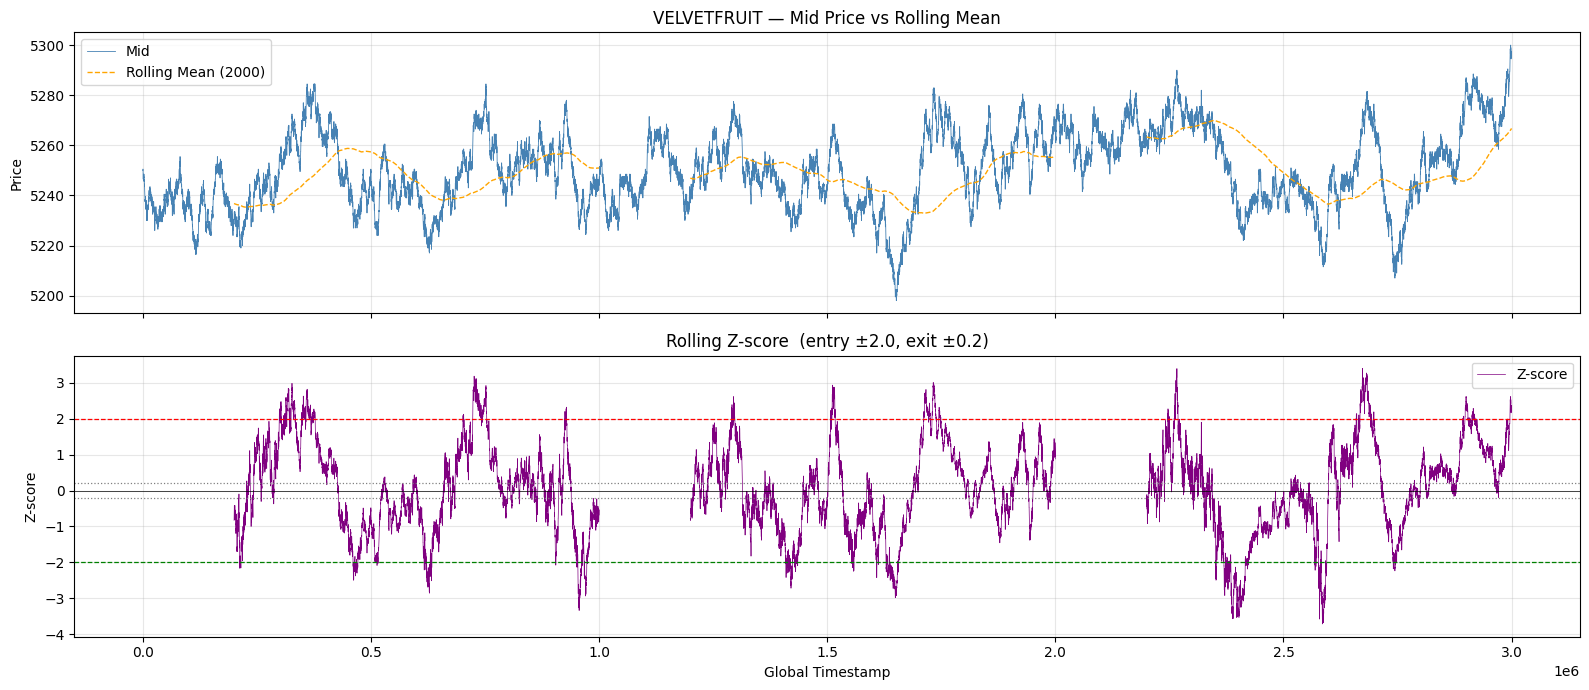

Valid z-score ticks: 24003 / 30000


In [37]:

# Parameters
WINDOW         = 2000    # rolling window for mean/std
Z_ENTER        = 2.0    # |z| threshold to open / increase position
Z_EXIT         = 0.2    # |z| threshold to force-close
Z_SCALE        = 3.0    # |z| at which target reaches ±POSITION_LIMIT
POSITION_LIMIT = 200

# Per-day rolling indicators (no cross-day contamination)
vf['rolling_mean_strat'] = vf.groupby('day')['mid'].transform(
    lambda x: x.rolling(WINDOW, min_periods=WINDOW).mean()
)
vf['rolling_std_strat'] = vf.groupby('day')['mid'].transform(
    lambda x: x.rolling(WINDOW, min_periods=WINDOW).std()
)
vf['z_strat'] = (vf['mid'] - vf['rolling_mean_strat']) / vf['rolling_std_strat']

# Preview signal
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
axes[0].plot(vf['global_timestamp'], vf['mid'], linewidth=0.6, color='steelblue', label='Mid')
axes[0].plot(vf['global_timestamp'], vf['rolling_mean_strat'], linewidth=1, color='orange',
             linestyle='--', label=f'Rolling Mean ({WINDOW})')
axes[0].set_ylabel('Price'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('VELVETFRUIT — Mid Price vs Rolling Mean')

axes[1].plot(vf['global_timestamp'], vf['z_strat'], linewidth=0.5, color='purple', label='Z-score')
for level, color, ls in [(Z_ENTER, 'red', '--'), (-Z_ENTER, 'green', '--'),
                          (Z_EXIT, 'gray', ':'), (-Z_EXIT, 'gray', ':')]:
    axes[1].axhline(level, color=color, linestyle=ls, linewidth=0.9)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Z-score'); axes[1].set_xlabel('Global Timestamp')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title(f'Rolling Z-score  (entry ±{Z_ENTER}, exit ±{Z_EXIT})')

plt.tight_layout(); plt.show()
print(f"Valid z-score ticks: {vf['z_strat'].notna().sum()} / {len(vf)}")


In [42]:

# Backtest
days     = vf['day'].values
bids     = vf['bid_price_1'].values
asks     = vf['ask_price_1'].values
bid_vols = vf['bid_volume_1'].values
ask_vols = vf['ask_volume_1'].values
mids     = vf['mid'].values
zs       = vf['z_strat'].values

position    = 0
cash        = 0.0
pnl_history = []
pos_history = []

for k in range(len(vf)):
    z, bid, ask = zs[k], bids[k], asks[k]
    bv, av      = bid_vols[k], ask_vols[k]

    if np.isnan(z) or np.isnan(bid) or np.isnan(ask) or np.isnan(bv) or np.isnan(av):
        pnl_history.append(cash + position * mids[k])
        pos_history.append(position)
        continue

    # Proportional contrarian target
    if abs(z) < Z_ENTER:
        target = position   # hold — dead band
    else:
        target = -int(np.clip(z / Z_SCALE * POSITION_LIMIT, -POSITION_LIMIT, POSITION_LIMIT))

    delta = target - position

    if delta > 0:
        fillable  = min(delta, int(av))
        cash     -= fillable * ask
        position += fillable
    elif delta < 0:
        fillable  = min(-delta, int(bv))
        cash     += fillable * bid
        position -= fillable

    pnl_history.append(cash + position * mids[k])
    pos_history.append(position)

# Close any open position at the last tick
if position != 0:
    cash += position * mids[-1]

vf['pnl_mr']      = pnl_history
vf['position_mr'] = pos_history

pnl_diff = vf['pnl_mr'].diff().dropna()
sharpe   = pnl_diff.mean() / pnl_diff.std()
max_dd   = (vf['pnl_mr'] - vf['pnl_mr'].cummax()).min()
n_trades = int((vf['position_mr'].diff().abs() > 0).sum())

print(f"Final PnL:         {vf['pnl_mr'].iloc[-1]:>12,.1f}")
print(f"Sharpe (per-tick): {sharpe:>12.4f}")
print(f"Max drawdown:      {max_dd:>12,.1f}")
print(f"Trades:            {n_trades:>12,}")


Final PnL:             18,913.0
Sharpe (per-tick):       0.0042
Max drawdown:         -17,942.0
Trades:                   2,394


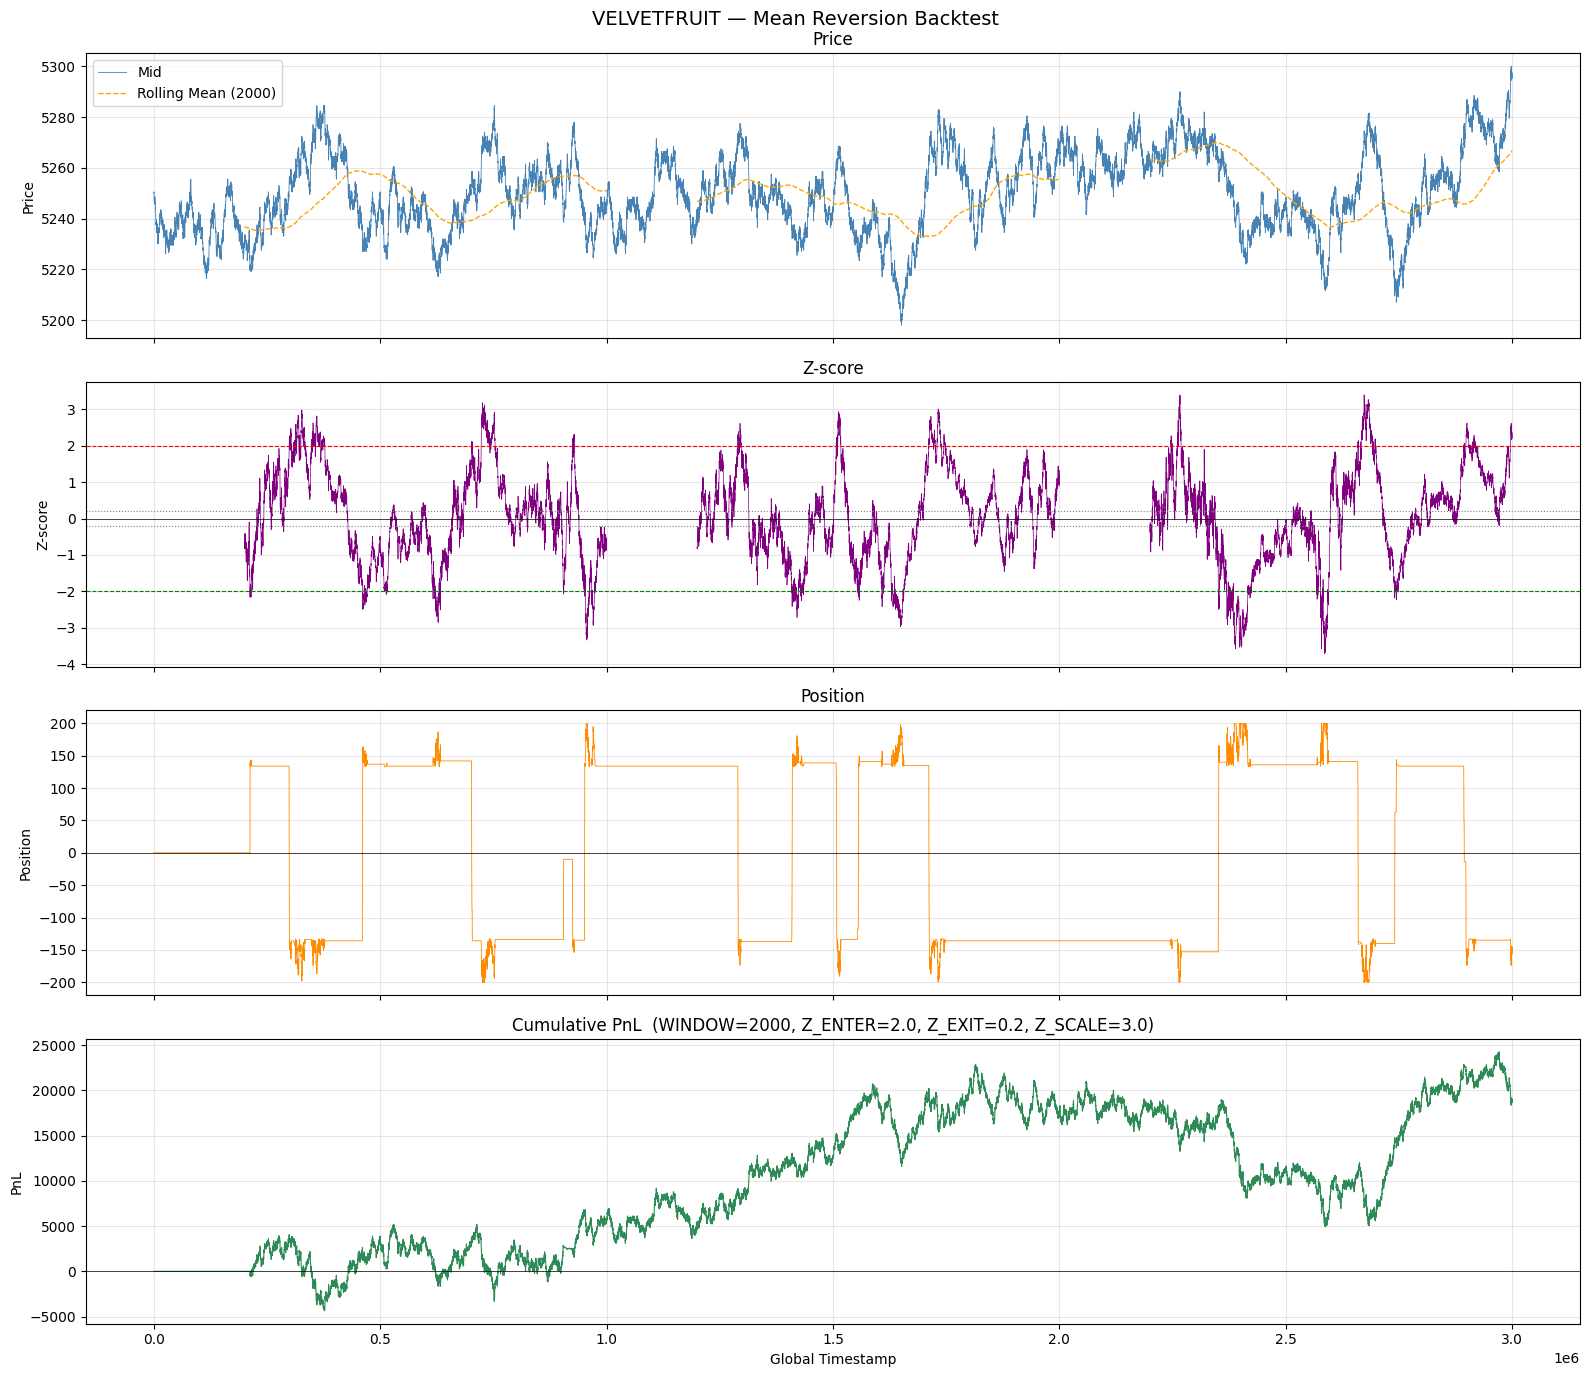

In [43]:

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axes[0].plot(vf['global_timestamp'], vf['mid'], linewidth=0.6, color='steelblue', label='Mid')
axes[0].plot(vf['global_timestamp'], vf['rolling_mean_strat'], linewidth=1, color='orange',
             linestyle='--', label=f'Rolling Mean ({WINDOW})')
axes[0].set_ylabel('Price'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Price')

axes[1].plot(vf['global_timestamp'], vf['z_strat'], linewidth=0.5, color='purple')
for level, c, ls in [(Z_ENTER,'red','--'),(-Z_ENTER,'green','--'),(Z_EXIT,'gray',':'),(-Z_EXIT,'gray',':')]:
    axes[1].axhline(level, color=c, linestyle=ls, linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('Z-score'); axes[1].grid(alpha=0.3)
axes[1].set_title('Z-score')

axes[2].plot(vf['global_timestamp'], vf['position_mr'], linewidth=0.6, color='darkorange')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Position'); axes[2].grid(alpha=0.3)
axes[2].set_title('Position')

axes[3].plot(vf['global_timestamp'], vf['pnl_mr'], linewidth=0.8, color='seagreen')
axes[3].axhline(0, color='black', linewidth=0.5)
axes[3].set_ylabel('PnL'); axes[3].set_xlabel('Global Timestamp'); axes[3].grid(alpha=0.3)
axes[3].set_title(f'Cumulative PnL  (WINDOW={WINDOW}, Z_ENTER={Z_ENTER}, Z_EXIT={Z_EXIT}, Z_SCALE={Z_SCALE})')

plt.suptitle('VELVETFRUIT — Mean Reversion Backtest', fontsize=14)
plt.tight_layout(); plt.show()


In [44]:

# Parameter sweep: WINDOW vs Z_EXIT heatmap
windows  = [50, 100, 200, 500, 1000, 2000, 5000]
z_exits  = [0.0, 0.1, 0.2, 0.5, 1.0]
Z_ENTER_SWEEP  = 2.0
Z_SCALE_SWEEP  = 3.0
POSITION_LIMIT_SWEEP = 200

bids_arr = vf['bid_price_1'].values
asks_arr = vf['ask_price_1'].values
bv_arr   = vf['bid_volume_1'].values
av_arr   = vf['ask_volume_1'].values
mids_arr = vf['mid'].values

# Precompute rolling mean/std for each window (per day, no cross-day contamination)
mean_cache = {}
std_cache  = {}
for w in windows:
    mean_cache[w] = vf.groupby('day')['mid'].transform(
        lambda x, _w=w: x.rolling(_w, min_periods=_w).mean()
    ).values
    std_cache[w] = vf.groupby('day')['mid'].transform(
        lambda x, _w=w: x.rolling(_w, min_periods=_w).std()
    ).values

pnl_grid = np.zeros((len(windows), len(z_exits)))

for i, w in enumerate(windows):
    means = mean_cache[w]
    stds  = std_cache[w]
    for j, ze in enumerate(z_exits):
        position = 0
        cash     = 0.0
        for k in range(len(vf)):
            m, s = means[k], stds[k]
            bid, ask = bids_arr[k], asks_arr[k]
            bv, av   = bv_arr[k], av_arr[k]
            if np.isnan(m) or np.isnan(s) or s == 0 or np.isnan(bid) or np.isnan(ask) or np.isnan(bv) or np.isnan(av):
                continue
            z = (mids_arr[k] - m) / s
            if abs(z) < ze:
                target = 0
            elif abs(z) < Z_ENTER_SWEEP:
                target = position
            else:
                target = -int(np.clip(z / Z_SCALE_SWEEP * POSITION_LIMIT_SWEEP, -POSITION_LIMIT_SWEEP, POSITION_LIMIT_SWEEP))
            delta = target - position
            if delta > 0:
                fillable = min(delta, int(av))
                cash    -= fillable * ask
                position += fillable
            elif delta < 0:
                fillable = min(-delta, int(bv))
                cash    += fillable * bid
                position -= fillable
        if position != 0:
            cash += position * mids_arr[-1]
        pnl_grid[i, j] = cash

print("PnL Grid (rows=WINDOW, cols=Z_EXIT):")
print(pd.DataFrame(pnl_grid, index=windows, columns=z_exits).to_string(float_format=lambda x: f"{x:,.0f}"))

best  = np.unravel_index(np.argmax(pnl_grid), pnl_grid.shape)
worst = np.unravel_index(np.argmin(pnl_grid), pnl_grid.shape)
print(f"\nBest:  WINDOW={windows[best[0]]}, Z_EXIT={z_exits[best[1]]}, PnL={pnl_grid[best]:,.0f}")
print(f"Worst: WINDOW={windows[worst[0]]}, Z_EXIT={z_exits[worst[1]]}, PnL={pnl_grid[worst]:,.0f}")


PnL Grid (rows=WINDOW, cols=Z_EXIT):
          0.0      0.1      0.2      0.5      1.0
50   -203,319 -292,415 -335,212 -380,411 -412,941
100  -150,932 -220,632 -249,112 -272,870 -304,114
200  -106,191 -155,185 -161,267 -172,637 -190,143
500   -30,134  -67,872  -70,752  -83,726  -91,606
1000    8,811  -24,558  -30,715  -43,659  -57,313
2000   18,913   -5,502   -6,972   -9,726  -23,785
5000   15,376    9,000    9,982    5,060    1,910

Best:  WINDOW=2000, Z_EXIT=0.0, PnL=18,913
Worst: WINDOW=50, Z_EXIT=1.0, PnL=-412,941


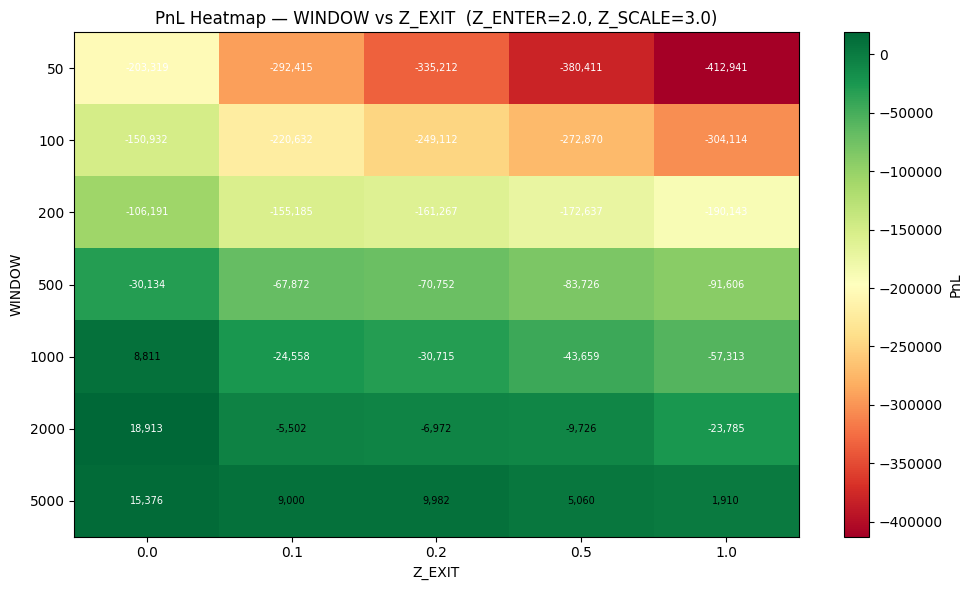

In [45]:

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pnl_grid, aspect='auto', cmap='RdYlGn')
plt.colorbar(im, ax=ax, label='PnL')

ax.set_xticks(range(len(z_exits)));  ax.set_xticklabels(z_exits)
ax.set_yticks(range(len(windows)));  ax.set_yticklabels(windows)
ax.set_xlabel('Z_EXIT'); ax.set_ylabel('WINDOW')
ax.set_title(f'PnL Heatmap — WINDOW vs Z_EXIT  (Z_ENTER={Z_ENTER_SWEEP}, Z_SCALE={Z_SCALE_SWEEP})')

for i in range(len(windows)):
    for j in range(len(z_exits)):
        ax.text(j, i, f'{pnl_grid[i,j]:,.0f}', ha='center', va='center', fontsize=7,
                color='black' if abs(pnl_grid[i,j]) < pnl_grid.max()*0.6 else 'white')

plt.tight_layout(); plt.show()
